In [1]:
import numpy as np
import scipy.sparse as sm
import numpy.linalg as la
import scipy.sparse.linalg as sml
import matplotlib.pyplot as plt
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

In [10]:
def Mat_AB(x,y,r):
    Nx , Ny = len(x)-2 , len(y)-2
    N = Nx*Ny
    A , B = np.zeros((N,N)) , np.zeros((N,N))
    d_A , d_B , mr= 1+4*r , 1-4*r , -r
    for i in range(Nx):
        for j in range(Ny):
            A[i*Ny + j ,i*Ny + j] , B[i*Ny + j,i*Ny + j] =  d_A , d_B
    for i in range(Nx-1):
        for j in range(Ny):
            A[(i+1)*Ny + j ,i*Ny + j] , B[(i+1)*Ny + j ,i*Ny + j] = mr , r
            A[i*Ny + j ,(i+1)*Ny + j] , B[i*Ny + j ,(i+1)*Ny + j] = mr , r
    for i in range(Nx):
        for j in range(Ny-1):
            A[i*Ny + j ,i*Ny + j+1] , B[i*Ny + j,i*Ny + j+1] =  mr , r
            A[i*Ny + j+1 ,i*Ny + j] , B[i*Ny + j+1,i*Ny + j] =  mr , r
    return A , B

def Met_CN_2D(x,y,t,Psi0,D=0.5):
    h2 = (x[1]-x[0])**2 # Ojo delta x y delta y tienen que ser iguales
    r = (D*(t[1]-t[0]))/h2
    sol = np.zeros( (len(x),len(y),len(t)) )
    sol[:,:,0] = Psi0
    print('Valor r=',r)
    if r < 1:
        A , B = Mat_AB(x,y,r)
        A , B = sm.csc_matrix(A) , sm.csc_matrix(B)
        A_inv = sml.inv(A)
        M_evol = A_inv@B
        Psi_vec_i = Psi2vec(Psi0,x,y)
        print('Evolucionando')
        for i in range(len(t)-1):
            # Solo evolucionar los puntos interiores
            Psi_vec_i = M_evol@Psi_vec_i
            sol[1:-1,1:-1,i+1] = vecPsi(Psi_vec_i,x,y)
    else:
        print('No hay convergencia')
    return sol

def Psi0(x,y):
    P0 = np.zeros( (len(x),len(y)) )
    for i in range(len(x)):
        for j in range(len(y)):
            if -0.25 < x[i] < 0.25 and -0.25 < y[j] < 0.25:
                P0[i,j] = 1
    return P0

def Psi2vec(P0,x,y):
    Nx , Ny = len(x)-2 , len(y)-2 #longitudes interiores
    Psi_in = P0[1:-1,1:-1]
    Psi_in_vec = Psi_in.transpose().reshape(1,Nx*Ny)[0]
    return Psi_in_vec

def vecPsi(vec,x,y):
    Nx , Ny = len(x)-2 , len(y)-2 #longitudes interiores
    Psi_in = vec.reshape(Ny,Nx).transpose()
    return Psi_in

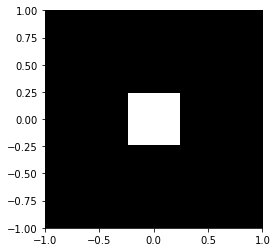

In [17]:
x , y = np.linspace(-1,1,50) , np.linspace(-1,1,50)
t = np.linspace(0,0.5,200)
P0 = Psi0(x,y)
plt.imshow( P0.transpose(),
           extent=(x[0],x[-1],y[0],y[-1]),
           origin='lower',
           cmap='bone',vmin=0,vmax=1)
plt.show()

In [18]:
Sol2DPsi = Met_CN_2D(x,y,t,P0)

Valor r= 0.7540829145728626
Evolucionando


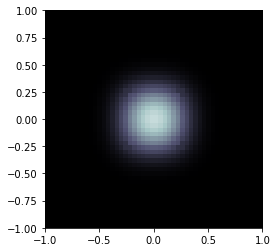

In [23]:
plt.imshow( Sol2DPsi[:,:,4].transpose(),
           extent=(x[0],x[-1],y[0],y[-1]),
           origin='lower',
           cmap='bone',vmin=0,vmax=1)
plt.show()

In [ ]:
A,B = Mat_AB(x,y,0.5)
A , B

In [89]:
A = np.arange(1,7)
A 

array([1, 2, 3, 4, 5, 6])

In [96]:
B = A.reshape(2,3)
B

array([[1, 2, 3],
       [4, 5, 6]])

In [97]:
B_vec = B.transpose().reshape(1,6)[0]
B_vec

array([1, 4, 2, 5, 3, 6])

In [100]:
B_vec.reshape(3,2).transpose()

array([[1, 2, 3],
       [4, 5, 6]])